<a href="https://colab.research.google.com/github/AndrewDavidRatnam/HuggingFace_IntroToAudioCourse/blob/main/HF_AudioCourse_Unit_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# WHATS A TRANSFORMER?


![ *TRANSFORMING NOISES*](https://38.media.tumblr.com/9993954525f45554eabec340292c3cde/tumblr_nophogdq8I1upqdo2o1_500.gif)


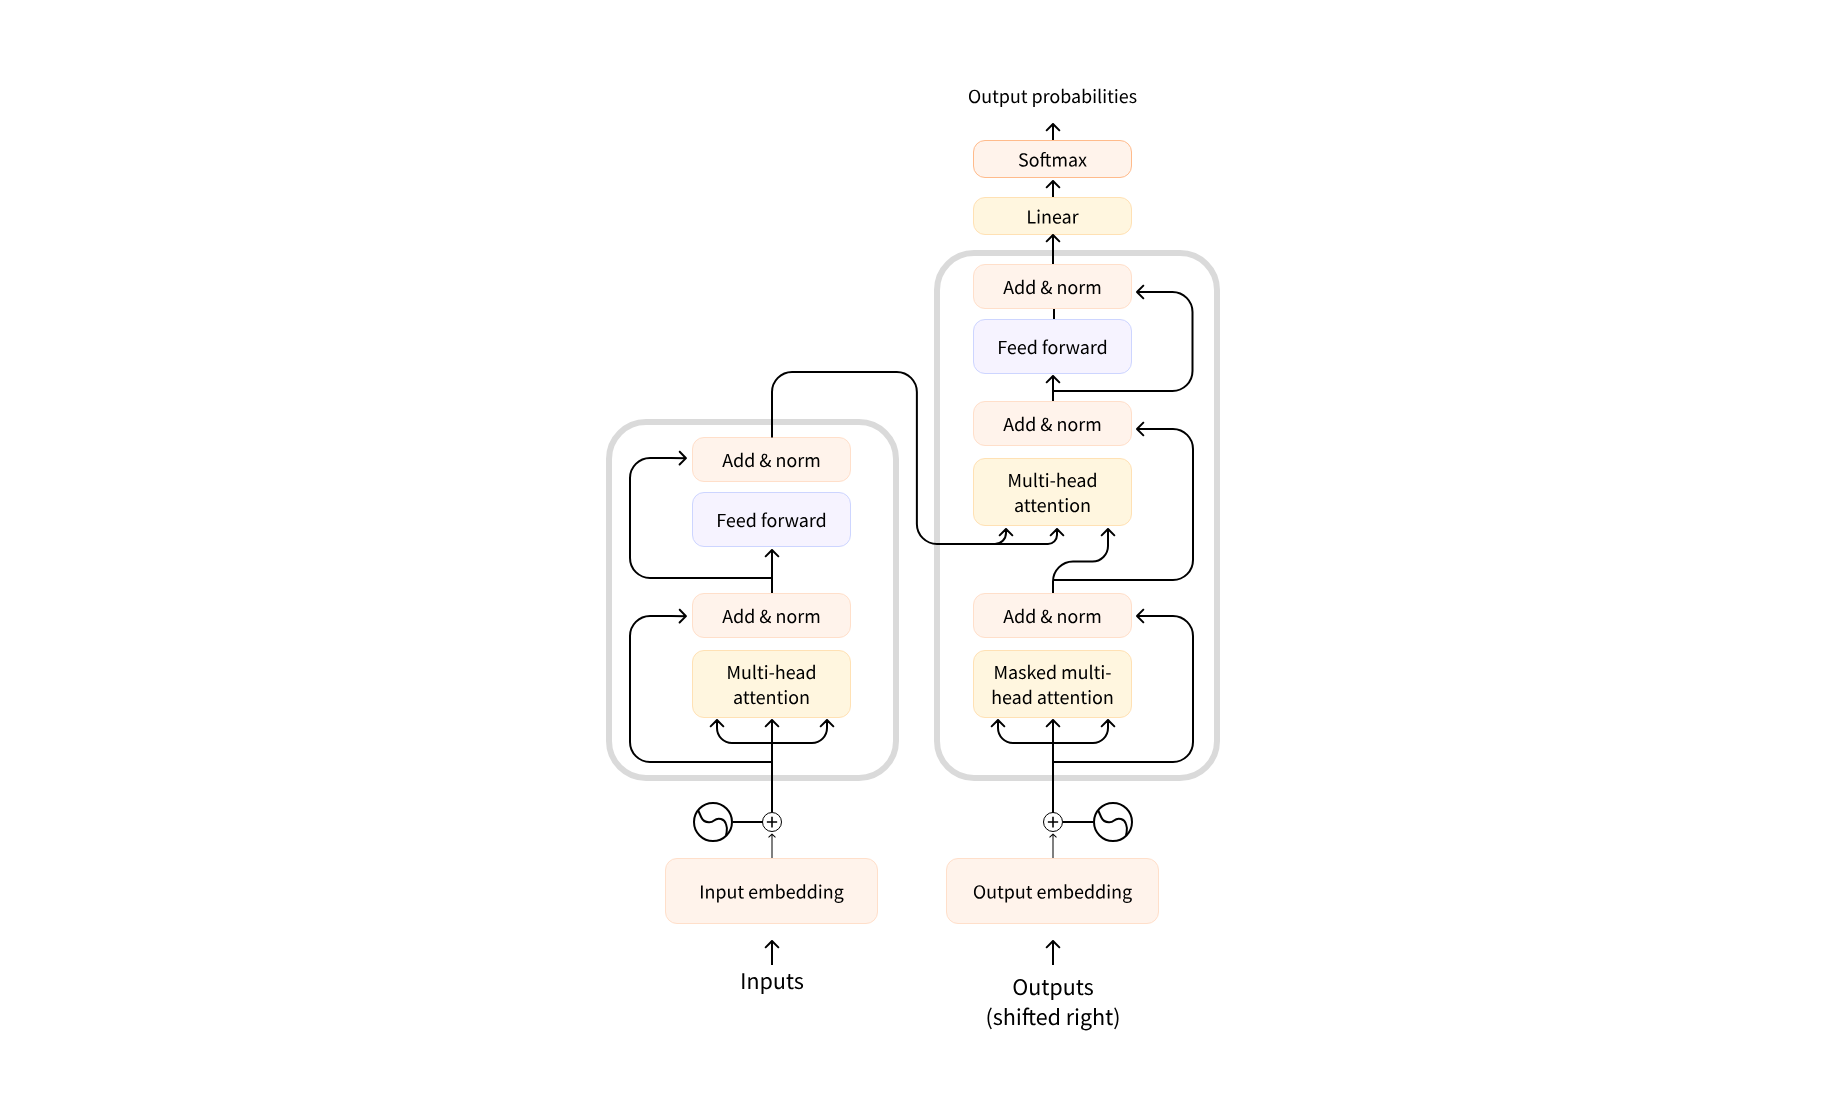

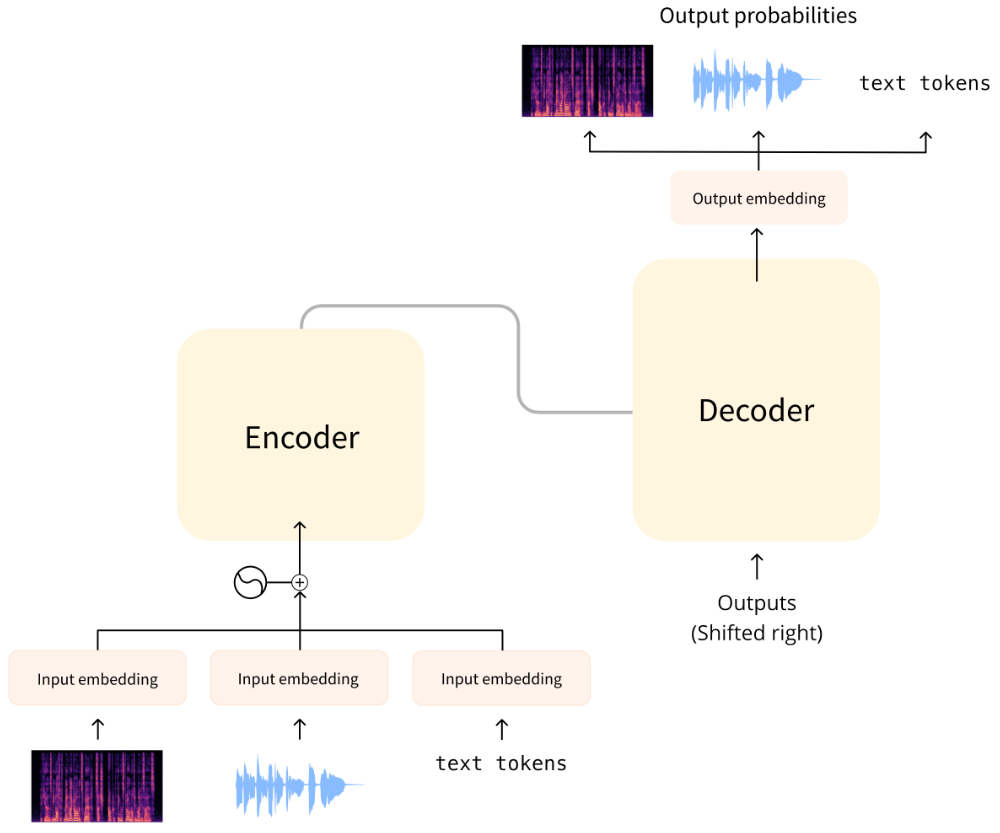

## Self Attention Head

In [1]:
import torch, torch.nn as nn
import torch.nn.functional as F
import math

class ScaledDotProductAttention(nn.Module):
  def forward(self, Q, K, V, mask=None):
    d_k = Q.size(-1)

    scores = torch.matmul(Q, K.transpose(-2, -1))/ math.sqrt(d_k) #the QK^t step

    if mask:
      scores = scores.masked_fill(mask == 0, float("-inf"))

      attn_weights = F.softmax(scores, dim=-1)

      output = torch.matmul(attn_weights, V)

      return output, attn_weights

## Multihead Attention used in almost every transformer block

In [ ]:
class MultiHeadAttention(nn.Module):
  def __init__(self, d_model=512, num_heads=8):
    super().__init__()
    self.d_k = d_model // num_heads
    self.num_heads = num_heads
    self.W_q = nn.Linear(d_model, d_model)
    self.W_k = nn.Linear(d_model, d_model)
    self.W_v = nn.Linear(d_model, d_model)
    self.W_o = nn.Linear(d_model, d_model)
    self.attention = ScaledDotProductAttention()

  def split_heads(self, x):
    B, T, D = x.shape
    return x.view(B, T, self.num_heads, self.d_k).transpose(1, 2)

  def forward(self, Q, K, V, mask=None):
    Q = self.split_heads(self.W_q(Q))
    K = self.split_heads(self.W_k(K))
    V = self.split_heads(self.W_v(V))

    out, _ = self.attention(Q,K,V,mask)
    B, H, T, dk = out.shape
    out = out.transpose(1,2).contiguous().view(B,T,H*dk)
    return self.W_o(out)




## Postion Wise Feed Forward

In [3]:
class PostionWiseFeedForward(nn.Module):
  def __init__(self, d_model=512, d_ff=2048, dropout=0.1):
    super().__init__()
    self.w_1 = nn.Linear(d_model, d_ff)
    self.w_2 = nn.Linear(d_ff, d_model)
    self.dropout = nn.Dropout(dropout)
    self.activation = nn.GELU()

  def forward(self, x):
    #(Batchsize, seq_len, d_modek)
    return self.w2(
        self.dropout(
        self.activation(
            self.w_1(x)
            )))


# CTC: Connectionist Temporal Classification Architecture
Wav2Vec/HuBERT etc

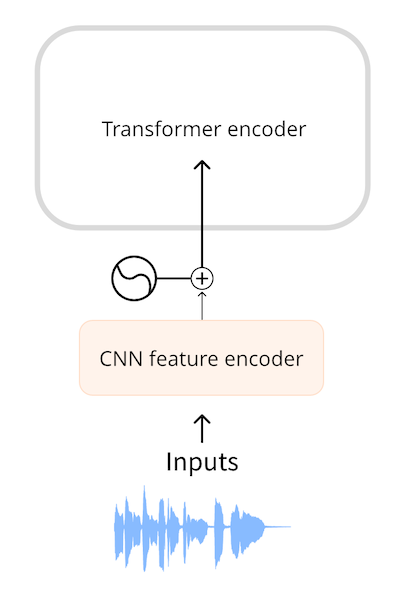

Only an Encoder and lowk classification head(Linear CTC) that outputs characters like 50(26 and some special tokens)

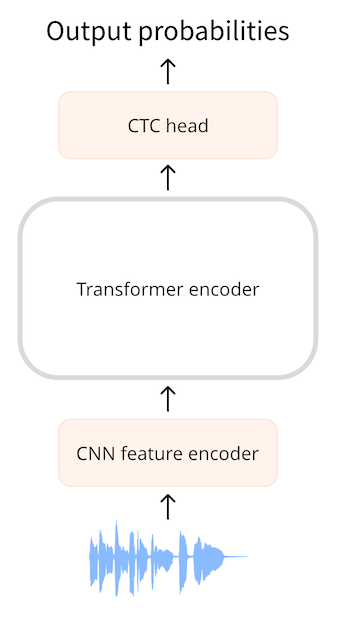

## CNN Feature Encoder

In [4]:
class Wav2Vec2_CNNEncoder(nn.Module):
  # (Batch, 1, num_samples)(1 sec) --> (Batch, T, 512) (T is 50 as 1 vec per 20ms)

  def __init__(self):
    super().__init__()
    conv_params = [
        (512,10,5),(512,3,2),(512,3,2),(512,3,2),(512, 3, 2),(512, 2, 2),(512, 2, 2)
    ]
    layers, in_ch = [], 1
    for out_ch, k , s in conv_params: #out, kernel, stride
      layers +=[nn.Conv1d(in_ch,out_ch, kernel_size = k ,stride = s), nn.GELU]
      in_ch = out_ch

    self.conv = nn.Sequential(*layers)

  def forward(self, waveform):
    x = waveform.unsqueeze(1) #(B, T) --> (B,1,T)
    x = self.conv(x)
    return x.transpose(1, 2) # (B, T', 512)